### Importação dos dados



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


In [ ]:
lojas = [loja, loja2, loja3, loja4]

for i, l in enumerate(lojas, start=1):
    faturamento = sum(l.Preço)
    print(f'Faturamento da loja{i}: R$ {faturamento:,.2f}')

Faturamento da loja1: R$ 1,534,509.12
Faturamento da loja2: R$ 1,488,459.06
Faturamento da loja3: R$ 1,464,025.03
Faturamento da loja4: R$ 1,384,497.58


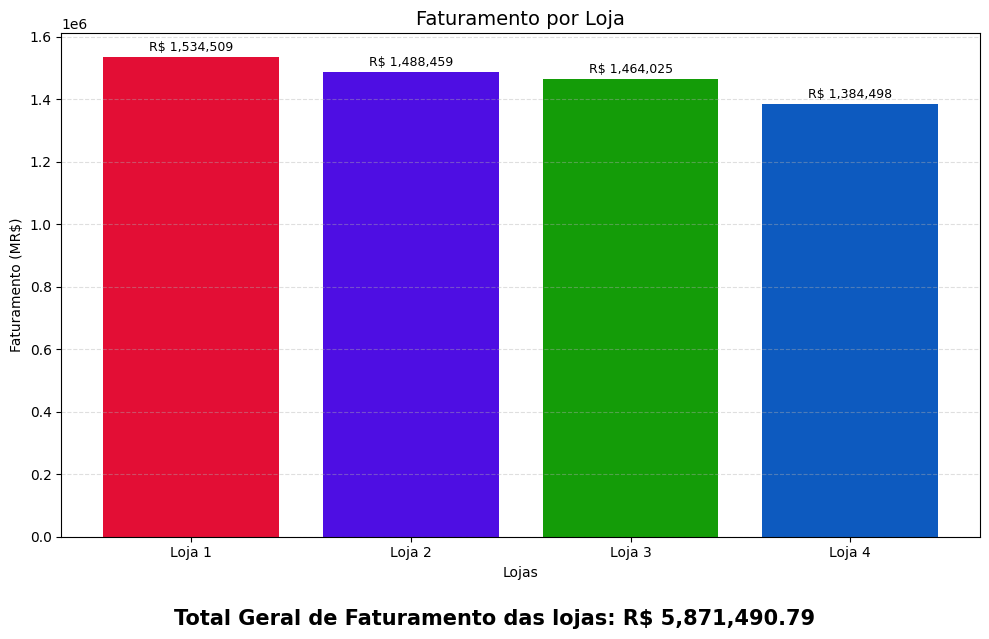

In [ ]:
import matplotlib.pyplot as plt


lojas = ["Loja 1", "Loja 2", "Loja 3", "Loja 4"]
faturamento = [1534509.12, 1488459.06, 1464025.03, 1384497.58]
cores = ['#E30E35', '#4E0EE3', '#149C08', '#0D5ABf']
total_geral = sum(faturamento)


plt.figure(figsize=(10,6))
plt.bar(lojas, faturamento, color=cores)


plt.title("Faturamento por Loja", fontsize=14)
plt.xlabel("Lojas")
plt.ylabel("Faturamento (MR$)")
plt.grid(axis='y', linestyle='--', alpha=0.4)


for i, valor in enumerate(faturamento):
    plt.text(i, valor + 10000, f"R$ {valor:,.0f}", ha='center', va='bottom', fontsize=9)


plt.figtext(0.5, -0.05, f"Total Geral de Faturamento das lojas: R$ {total_geral:,.2f}",
            ha="center", fontsize=15, weight='bold', color='black')


plt.tight_layout()
plt.savefig("faturamento_lojas.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. Vendas por Categoria


In [ ]:
def produtos_categoria(loja, nome_loja):

  vendas_categoria = loja.groupby('Categoria do Produto').size().reset_index(name='Quantidade de Vendas')
  vendas_categoria = vendas_categoria.sort_values(by='Quantidade de Vendas', ascending=False)
  print(f'As categorias mais populares da loja {nome_loja} são:')
  print(vendas_categoria)
  return vendas_categoria

vendas_cat_loja1 = produtos_categoria(loja, 'Loja 1')
vendas_cat_loja2 = produtos_categoria(loja2, 'Loja 2')
vendas_cat_loja3 = produtos_categoria(loja3, 'Loja 3')
vendas_cat_loja4 = produtos_categoria(loja4, 'Loja 4')

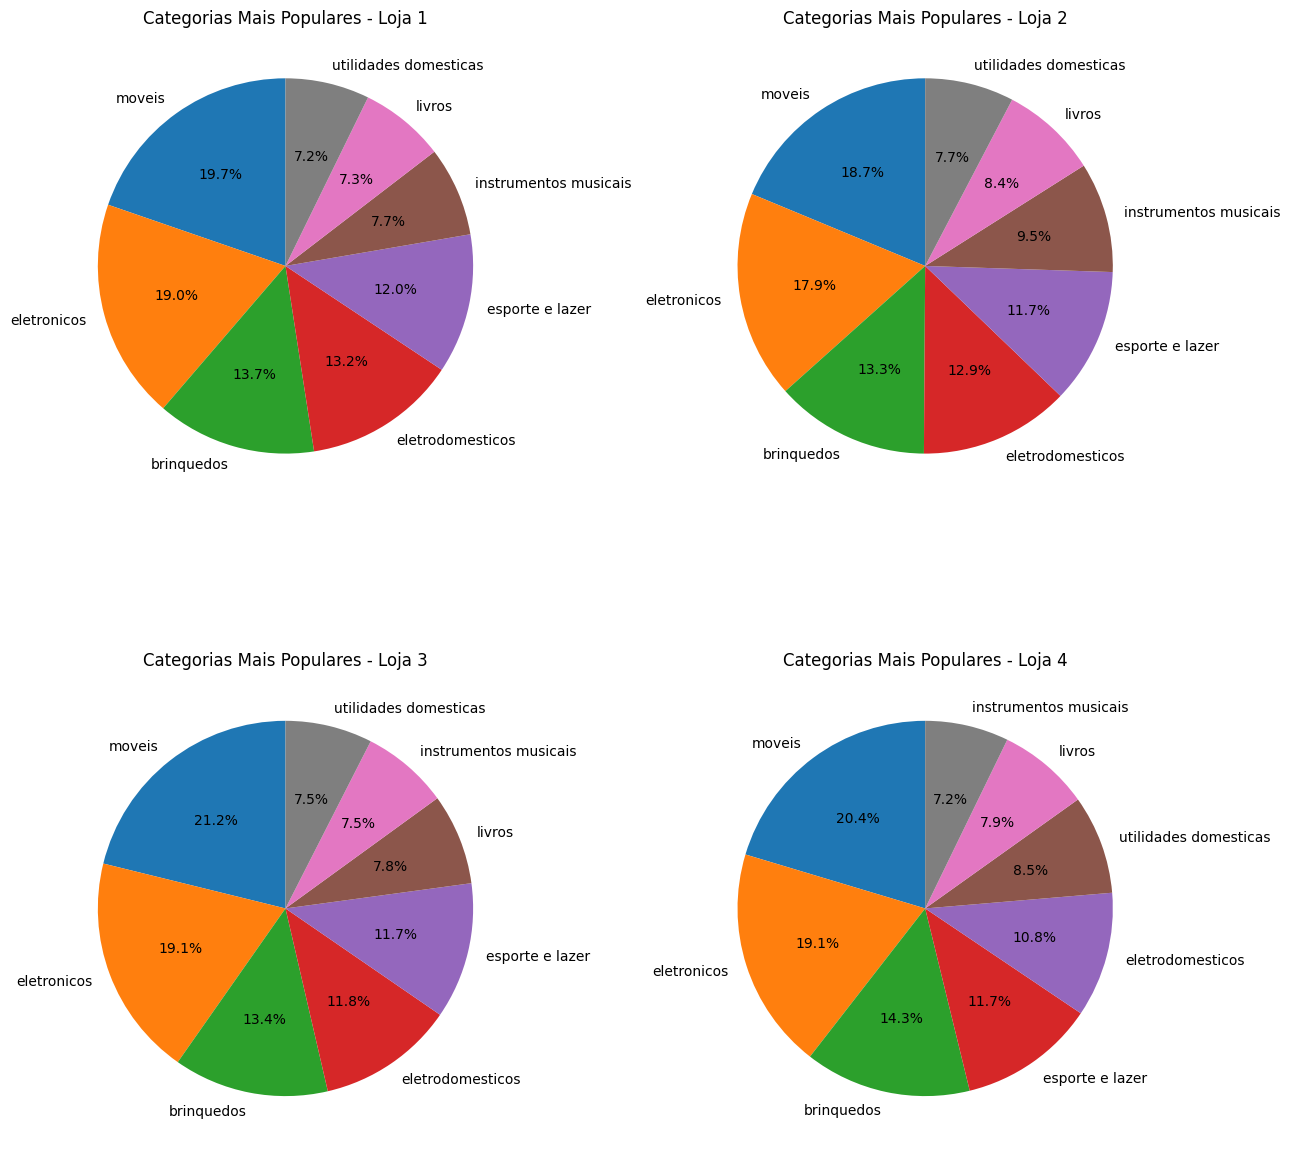

In [ ]:
import matplotlib.pyplot as plt

lojas_data = [
    (loja, 'Loja 1'),
    (loja2, 'Loja 2'),
    (loja3, 'Loja 3'),
    (loja4, 'Loja 4')
]

fig, axes = plt.subplots(2, 2, figsize=(13, 13))

for i, (loja_df, nome_loja) in enumerate(lojas_data):

    vendas_categoria = loja_df.groupby('Categoria do Produto').size().reset_index(name='Quantidade de Vendas')
    vendas_categoria = vendas_categoria.sort_values(by='Quantidade de Vendas', ascending=False)


    linha = i // 2
    coluna = i % 2


    axes[linha, coluna].pie(vendas_categoria['Quantidade de Vendas'],
                            labels=vendas_categoria['Categoria do Produto'],
                            autopct='%1.1f%%',
                            startangle=90)
    axes[linha, coluna].set_title(f'Categorias Mais Populares - {nome_loja}')


plt.tight_layout()
plt.savefig("vendas_categoria.png", dpi=300, bbox_inches='tight')
plt.show()

# 3. Média de Avaliação das Lojas

In [ ]:
def avaliacao_media(loja, nome_loja):

  media_loja = loja['Avaliação da compra'].mean()
  print(f'Média da {nome_loja}: {media_loja: .2f}')

avaliacao_media(loja, 'Loja 1')
avaliacao_media(loja2, 'Loja 2')
avaliacao_media(loja3, 'Loja 3')
avaliacao_media(loja4, 'Loja 4')

Média da Loja 1:  3.98
Média da Loja 2:  4.04
Média da Loja 3:  4.05
Média da Loja 4:  4.00


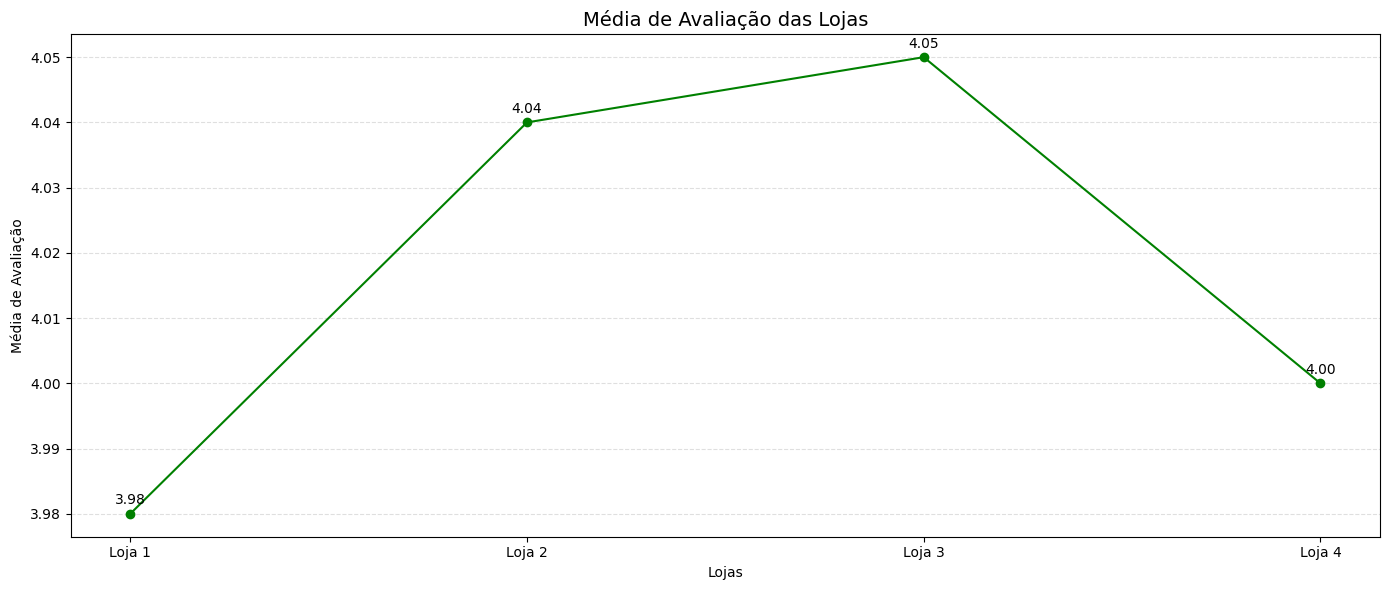

In [ ]:
import matplotlib.pyplot as plt


lojas = ["Loja 1", "Loja 2", "Loja 3", "Loja 4"]
media_loja = [3.98, 4.04, 4.05, 4.00]


plt.figure(figsize=(14,6))
plt.plot(lojas, media_loja, marker = 'o', linestyle = '-', color='g', markersize = 6)


plt.title("Média de Avaliação das Lojas", fontsize=14)
plt.xlabel("Lojas")
plt.ylabel("Média de Avaliação")
plt.grid(axis='y', linestyle='--', alpha=0.4)


for i, valor in enumerate(media_loja):
    plt.text(lojas[i], valor +0.001, f'{valor:.2f}', ha='center', va='bottom', fontsize=10)


plt.tight_layout()
plt.savefig("media_avaliacao_lojas.png", dpi=300, bbox_inches='tight')
plt.show()

# 4. Produtos Mais e Menos Vendidos

In [ ]:
def produtos_vendidos(loja, nome_loja):

  vendas_por_produto = loja.groupby('Produto')['Produto'].count()

  produto_mais_vendido = vendas_por_produto.idxmax()
  qtd_mais_vendido = vendas_por_produto.max()

  produto_menos_vendido = vendas_por_produto.idxmin()
  qtd_menos_vendido = vendas_por_produto.min()

  print(f"\n{nome_loja}:")
  print(f"Produto mais vendido: {produto_mais_vendido} ({qtd_mais_vendido} unidades)")
  print(f"Produto menos vendido: {produto_menos_vendido} ({qtd_menos_vendido} unidades)")

  return produto_mais_vendido, produto_menos_vendido, qtd_mais_vendido, qtd_menos_vendido

mais_vendido, menos_vendido, qtd_mais_vendido, qtd_menos_vendido = produtos_vendidos(loja, "Loja 1")
mais_vendido2, menos_vendido2, qtd_mais_vendido2, qtd_menos_vendido2 = produtos_vendidos(loja2, "Loja 2")
mais_vendido3, menos_vendido3, qtd_mais_vendido3, qtd_menos_vendido3 = produtos_vendidos(loja3, "Loja 3")
mais_vendido4, menos_vendido4, qtd_mais_vendido4, qtd_menos_vendido4 = produtos_vendidos(loja4, "Loja 4")


Loja 1:
Produto mais vendido: Guarda roupas (60 unidades)
Produto menos vendido: Celular ABXY (33 unidades)

Loja 2:
Produto mais vendido: Iniciando em programação (65 unidades)
Produto menos vendido: Jogo de tabuleiro (32 unidades)

Loja 3:
Produto mais vendido: Kit banquetas (57 unidades)
Produto menos vendido: Blocos de montar (35 unidades)

Loja 4:
Produto mais vendido: Cama box (62 unidades)
Produto menos vendido: Guitarra (33 unidades)


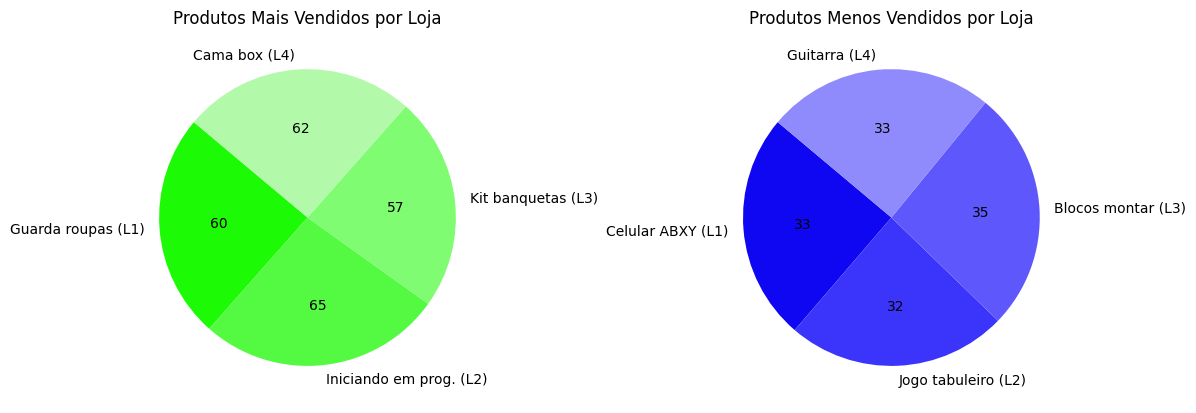

In [ ]:
import matplotlib.pyplot as plt

produtos_mais = ["Guarda roupas (L1)", "Iniciando em prog. (L2)", "Kit banquetas (L3)", "Cama box (L4)"]
vendas_mais = [60, 65, 57, 62]

produtos_menos = ["Celular ABXY (L1)", "Jogo tabuleiro (L2)", "Blocos montar (L3)", "Guitarra (L4)"]
vendas_menos = [33, 32, 35, 33]

cores_mais = ['#1DFA05', '#53FA41', '#7FFC72', '#B2FAAA']
cores_menos = ['#0F07F2', '#3B34FA', '#5E58FC', '#8F8BFC']

def only_value_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val}'
    return my_format

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.pie(vendas_mais, labels=produtos_mais, autopct=only_value_format(vendas_mais),
        startangle=140, colors=cores_mais)
plt.title('Produtos Mais Vendidos por Loja')

plt.subplot(1, 2, 2)
plt.pie(vendas_menos, labels=produtos_menos, autopct=only_value_format(vendas_menos),
        startangle=140, colors=cores_menos)
plt.title('Produtos Menos Vendidos por Loja')

plt.tight_layout()
plt.savefig("produtos_mais_menos_vendidos.png", dpi=300, bbox_inches='tight')
plt.show()

# 5. Frete Médio por Loja


In [ ]:
def media_frete(loja, nome_loja):
    """
    Função para calcular e exibir a média de frete de uma loja.

    Parâmetros:
    loja (DataFrame): O DataFrame contendo os dados da loja.
    nome_loja (str): Nome da loja para exibição.
    """
    frete = loja['Frete'].mean()
    print(f'Média de Frete para {nome_loja}: {round(frete, 2)}')

lojas = [(loja, 'Loja 1'), (loja2, 'Loja 2'), (loja3, 'Loja 3'), (loja4, 'Loja 4')]

for loja, nome in lojas:
    media_frete(loja, nome)

Média de Frete para Loja 1: 34.69
Média de Frete para Loja 2: 33.62
Média de Frete para Loja 3: 33.07
Média de Frete para Loja 4: 31.28


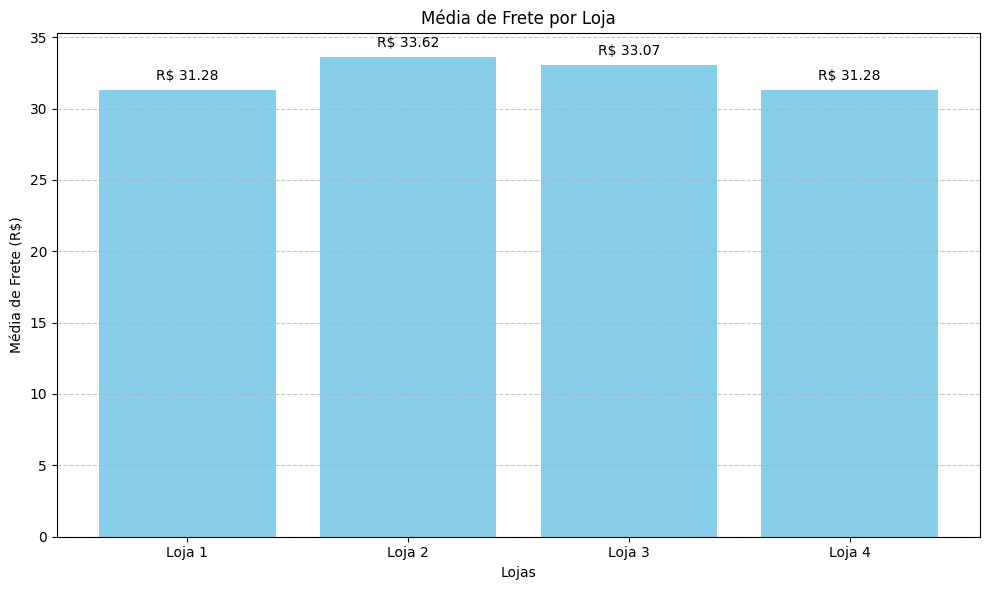

In [ ]:
import matplotlib.pyplot as plt

lojas_data = [
    (loja, 'Loja 1'),
    (loja2, 'Loja 2'),
    (loja3, 'Loja 3'),
    (loja4, 'Loja 4')
]

medias_frete = [loja_df['Frete'].mean() for loja_df, _ in lojas_data]
nomes_lojas = [nome_loja for _, nome_loja in lojas_data]

plt.figure(figsize=(10, 6))
plt.bar(nomes_lojas, medias_frete, color='skyblue')


plt.title('Média de Frete por Loja')
plt.xlabel('Lojas')
plt.ylabel('Média de Frete (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, valor in enumerate(medias_frete):
    plt.text(i, valor + 0.5, f'R$ {valor:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("media_frete_lojas.png", dpi=300, bbox_inches='tight')
plt.show()